In [1]:
import os
import sys
import argparse

import numpy as np
import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

In [2]:
from data_generation.differential_equations import PoissonSetup2LeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, project
from utils import evaluate_expression

import scifem
from scifem import create_real_functionspace

import torch
import numpy as np
from petsc4py import PETSc

from utils import save_npy
import matplotlib.pyplot as plt

----------------------------------------
2025-10-08 23:31:10 - Start Program
----------------------------------------


In [ ]:
mesh_config_path= repo_path + "/configs/poisson_setup2/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup2/config_data/config_function_space.yaml"
train_dataset_path = repo_path + "/results/poisson_setup2/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup2/test_dataset"

In [4]:
mesh_args = load_yaml(mesh_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 256, 256
function_space_args = load_yaml(function_space_config_path)
poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates_256x256.npy")
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
perm = [np.where((dolfin_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [5]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    m_vertex_values = load_npy(dataset_path + "/m_vertex_values_256x256.npy")
    
    scale = 2
    image_m_vertex_values = m_vertex_values.reshape(-1, mesh_args['num_y'] + 1, mesh_args['num_x'] + 1)
    downsampled_image_m_vertex_values = image_m_vertex_values[:, ::scale, ::scale]
    downsampled_num_y, downsampled_num_x = downsampled_image_m_vertex_values.shape[1] - 1, downsampled_image_m_vertex_values.shape[2] - 1
    downsampled_m_vertex_values = downsampled_image_m_vertex_values.reshape(-1, (downsampled_num_y + 1) * (downsampled_num_x + 1))
    downsampled_dolfin_mesh_coords = dolfin_mesh_coords.reshape(mesh_args['num_y'] + 1, mesh_args['num_x'] + 1, 2)[::scale, ::scale, :].reshape(-1, 2)
    save_npy(dataset_path + "/m_vertex_values.npy", downsampled_m_vertex_values)
    save_npy(dataset_path + "/mesh_coordinates.npy", downsampled_dolfin_mesh_coords)
    print(f"Saved downsampled m_vertex_values with shape: {downsampled_m_vertex_values.shape}")


Saved downsampled m_vertex_values with shape: (5000, 16641)
Saved downsampled m_vertex_values with shape: (500, 16641)


In [6]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    m_vertex_values = load_npy(dataset_path + "/m_vertex_values_256x256.npy")

    num_functions = len(m_vertex_values)
    m_dim = dolfinx.fem.Function(Vh['m']).x.array.shape[0]
    m_dof = np.zeros((num_functions, m_dim), dtype=np.float64)

    for i in range(num_functions):
        m_fc = dolfinx.fem.Function(Vh['m'])
        m_fc.x.array[:] = m_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['m'])]
        m_dof[i] = m_fc.x.array[:]

    save_npy(dataset_path + "/m_dof_256x256.npy", m_dof)


In [7]:
mesh_args = load_yaml(mesh_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 128, 128
function_space_args = load_yaml(function_space_config_path)
poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates.npy")
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
perm = [np.where((dolfin_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [8]:
for dataset_path in [train_dataset_path, test_dataset_path]:
    m_vertex_values = load_npy(dataset_path + "/m_vertex_values.npy")

    num_functions = len(m_vertex_values)
    m_dim = dolfinx.fem.Function(Vh['m']).x.array.shape[0]
    m_dof = np.zeros((num_functions, m_dim), dtype=np.float64)

    for i in range(num_functions):
        m_fc = dolfinx.fem.Function(Vh['m'])
        m_fc.x.array[:] = m_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['m'])]
        m_dof[i] = m_fc.x.array[:]

    save_npy(dataset_path + "/m_dof.npy", m_dof)

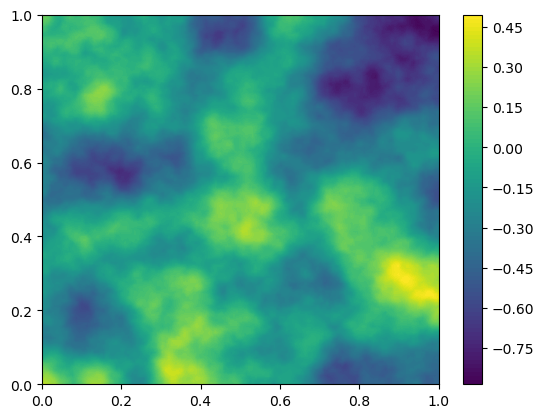

In [9]:
x = mesh.geometry.x[:, 0]
y = mesh.geometry.x[:, 1]
plt.tricontourf(x, y, evaluate_expression(mesh, m_fc, mesh.geometry.x)[1][:, 0], cmap='viridis', levels=100)
plt.colorbar()
plt.show()

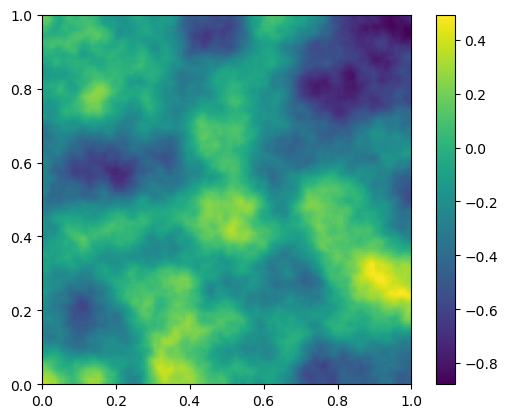

In [10]:
plt.imshow(m_vertex_values[-1].reshape(mesh_args['num_y'] + 1, mesh_args['num_x'] + 1), origin='lower', cmap='viridis', extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']))
plt.colorbar()
plt.show()

In [11]:
# dtype = 'float64'
# for i in range(3):
#     m = dolfinx.fem.Function(Vh['m'], dtype=dtype)
#     m.x.array[:] = m_dof[i,:]

#     p = dolfinx.fem.Function(Vh['p'], dtype=dtype)
#     project(poisson_least_squares.permeability(m), p)

#     sigma_u = poisson_least_squares.solve_sigma_u(p=p)
#     sigma = sigma_u.sub(0).collapse()
#     u = sigma_u.sub(1).collapse()
#     u.name = 'u'
#     plotter = plot_real_valued_function(u, Vh['u'])

In [12]:
# plotter = plot_real_valued_function(k, Vh['k'])